Proyecto Final IRN por:

Franco Marbán Jesús Leonardo y

López Villegas Fernando Maximiliano

# **Clasificación de imágenes del clima**

# Preprocesamiento


Una vez que acomodamos los datos de:

> Ajayi, Gbeminiyi (2018), “Multi-class Weather Dataset for Image Classification”, Mendeley Data, V1, doi: 10.17632/4drtyfjtfy.1
usando PARCEVAL.ipynb


> https://github.com/n0teventrying/FP_TSAF-2024_V2




## Descargar base de datos

In [ ]:
import numpy as np  # Manipulación de matrices y operaciones matemáticas.
import os  # Interacción con el sistema operativo, como lectura/escritura de archivos y manejo de directorios.
import PIL  # Trabajo con imágenes, incluyendo apertura, manipulación y guardado de formatos de imagen.
import PIL.Image  # Módulo específico de PIL para manipular imágenes.
import tensorflow as tf
import tensorflow_datasets as tfds  # Acceso y trabajo con conjuntos de datos preexistentes para TensorFlow.
import keras  # Construcción y entrenamiento de redes neuronales con una API de alto nivel.
from tensorflow.keras import layers  # Construcción de arquitecturas de redes neuronales utilizando capas.
import pathlib  # Interfaz orientada a objetos para trabajar con rutas de archivos y directorios.

import matplotlib.pyplot as plt  # Creación de visualizaciones y gráficos en Python.


In [ ]:
#Una vez que limpiamos y organizamos la base de datos con PARCEVAL.ipynb
#Lo subimos a github para un acceso más efficiente
#Tenemos dos tipos de bases de datos, una organizada que considera todas las imagenes:

#dataset_url = "https://github.com/n0teventrying/FP_TSAF-2024_V2/raw/main/WeatherDataSet_Organized.zip"

#Y esta otra que toma el número máximo de la clase más pequeña para que no haya necesidad de implementar una custom loss function

#Donde se ubica el archivo
dataset_url = "https://github.com/n0teventrying/FP_TSAF-2024_V2/raw/main/WeatherDataSet_Balanced.zip"
#Lo descargamos y descomprimimos
archive = tf.keras.utils.get_file(origin=dataset_url, extract=True)
#Ocupamos saber donde está, y eso hace la siguiente linea
data_dir = pathlib.Path(archive).with_suffix('')

76694660/76694660 [==============================] - 0s 0us/step


In [ ]:
#Si bien ya se hizo la limpieza en PARCEVAL, puede que no se haya hecho bien.
#Hubo un momento donde la clase sunrise tenia 2700 imagenes, el set original tenia menos de 1500 ._.
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

860


In [ ]:
batch_size = 32 # No es necesario hacer esto, porque dejamos que la utileria usara el default que es 32
#A pesar del analisis de dimensiones de las imagenes, decidimos dejar 244 por convención y prque nuestro
#conjunto de datos es pequeño para un modelo de Deep Learning, iba a haber overfitting.
img_height = 224
img_width = 224

## Conjunto de entrenamiento, validación y prueba

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
#Usamos lo que viene en la documentación de tensorflow porque no es una base de datos niche

seed_train_validation = 123 #Para que no difiera cada vez que corremos el código
shuffle_value = True #Necesitamos que el llenado sea aleatorio y no haya bias por no hacerlo
validation_split = 0.3 # Queremos 70% para entrenar la red convulocional
directory = data_dir # El directorio donde tenemos nuestra base descomprimida

#El procedimiento es sencillo, ojo que esto solo nos va a dar dos conjuntos, el de validacion y entrenamiento
train_ds = tf.keras.utils.image_dataset_from_directory(
directory,# de donde va a sacar las imagenes
image_size = (img_height, img_width), #el tamaño en el que deben estar las imagenes (si, las convierte)
validation_split = validation_split, #le dejamos sabe que tanto se puede dar a entrenamiento
subset = "training", #que conjunto es este
seed = seed_train_validation, # la semilla para reproducibilidad en cada compilación
color_mode = 'rgb', #son imagenes a color
shuffle = shuffle_value) #llenado aleatorio

#Este es analogo, pero difiere en que este es el de validación
val_ds = tf.keras.utils.image_dataset_from_directory(
directory,
image_size = (img_height, img_width),
validation_split = validation_split,
subset = "validation", #aquí le decimos que es el de validación
seed = seed_train_validation,
color_mode = 'rgb',
shuffle = shuffle_value)

Found 860 files belonging to 4 classes.
Using 602 files for training.
Found 860 files belonging to 4 classes.
Using 258 files for validation.


In [ ]:
#Como lo podemos ver, los separo en batches de 32 imagenes cada uno (aproximadamente)
print(len(train_ds))
print(len(val_ds))


19
9


In [ ]:
#También se separan los datos de prueba, usamos los batches de validación
val_batches = tf.data.experimental.cardinality(val_ds)
# Toma los primeros dos tercios del conjunto de datos de validación para crear el conjunto de prueba (test_ds).
test_ds = val_ds.take((2*val_batches) // 3)
# Omite los primeros dos tercios del conjunto de datos de validación
val_ds = val_ds.skip((2*val_batches) // 3)

In [ ]:
#Chacamos la distribución de batches
print(len(train_ds))
print(len(val_ds))
print(len(test_ds))

19
3
6


In [ ]:
#Confirmamaos cuantas imagenes hay en cada conjunto, para eso hacemos lo siguiente:

# Las sacamos de los batches y las contamos con un for loop
#Para entrenamiento
total_train_images = sum(1 for _ in train_ds.unbatch())

#Para validación
total_val_images = sum(1 for _ in val_ds.unbatch())

#Para prueba
total_test_images = sum(1 for _ in test_ds.unbatch())

print("Imagenes en el conjunto de entrenamiento:", total_train_images)
print("Imagenes en el conjunto de validación:", total_val_images)
print("Imagenes en el conjunto de prueba:", total_test_images)


Imagenes en el conjunto de entrenamiento: 602
Imagenes en el conjunto de validación: 66
Imagenes en el conjunto de prueba: 192


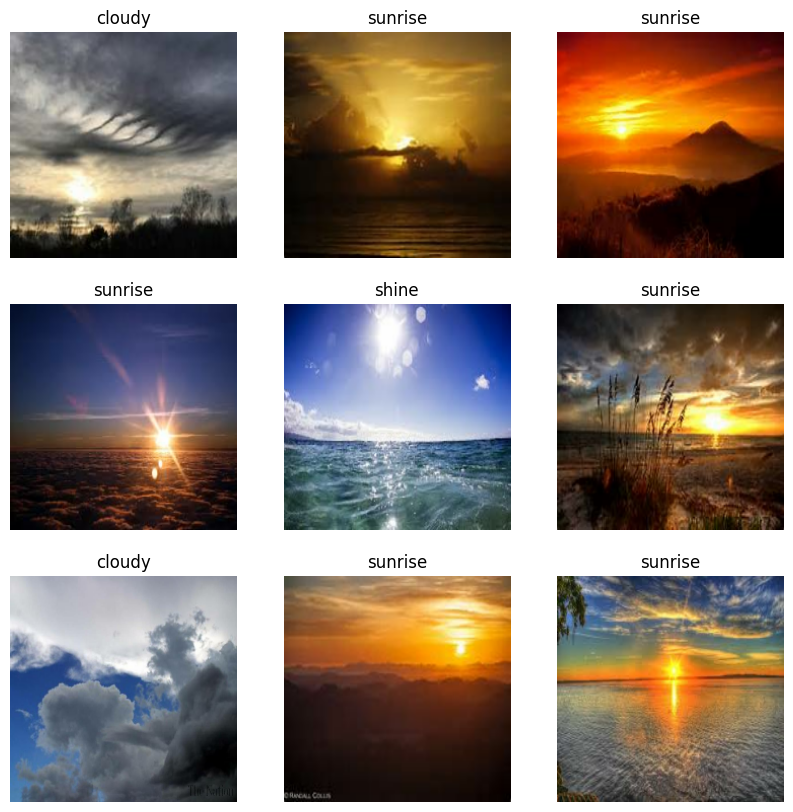

In [ ]:
#Breve visualización de las imágenes del dataset
plt.figure(figsize=(10, 10))  #dimensiones de 10x10
for images, labels in train_ds.take(1):  # Usamos el primer batch
  for i in range(9):  # usamos 9 imagenes del batch
    ax = plt.subplot(3, 3, i + 1)  # Hacemos cuadrícula de 3x3
    plt.imshow(images[i].numpy().astype("uint8"))  # La plotemaos en unit8 (sino no jala)
    plt.title(train_ds.class_names[labels[i]])  # les ponemos nombre xd
    plt.axis("off")  # no axis LOL


In [ ]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 224, 224, 3)
(32,)


In [ ]:
#lo que esparamos, un batch de 32 imagenes de dimensiones 244x244 y con 3 canales de color RGB
#y sus respectivas labels

## Normalization Layer

In [ ]:
#Esto solo es para acentuar que se debe incluir en la red neuronal,
#porque al ser imagenes los pixeles van de 0 a 255, y la red se siente mejor comiendo datos entre 0 y 1
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [ ]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)) #Solo ocupamos las imagenes, no las etiquetas
image_batch, labels_batch = next(iter(normalized_ds)) #los guardamos
first_image = image_batch[0] #tomamos una muestra
print(np.min(first_image), np.max(first_image)) #mucho ojo, que si sale

0.2784314 1.0


## Almacenamos los datos en caché y precargamos los batches de datos.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE  # Ajuste automático para optimizar el rendimiento.

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)  # Almacena y precarga datos para entrenar más rápido.
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)  # Almacena y precarga datos para validar más rápido.
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)  # Almacena y precarga datos para probar más rápido.

# Modelo 1: Un acercamiento simple

In [ ]:
num_classes = 4 #numero de clases xd

## Modelo 1

In [ ]:
#Vamos a coonstruir nuestro modelo con la clásica combinación de Conv2D y MaxPooling2D
def create_model1(num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Rescaling(1./255), #Nuestra capa de normalización
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),     #Usamos 32 flitros, de 3x3 con relu para la no linearidad
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),     #No hay una razón muy concreta de porque subimos el número de filtros
        tf.keras.layers.MaxPooling2D(),                            #pero, si no lo hacemos el desempeño de la red disminuye
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(),
         tf.keras.layers.Conv2D(256, (3, 3), activation='relu'), #Podemos ver que hay una 4ta capa, en realidad esto no ayuda
        tf.keras.layers.MaxPooling2D(),                          #porque puede haber overfitting, que no paso en nuestro caso sino que su desempeño en promedio era mermado, por eso la dejamos, para que se viera que no sirve tanto.
        tf.keras.layers.Flatten(),                              #Despues de eso ocupamos usar lo que aprendio, las aplana en un vector 1D
        tf.keras.layers.Dense(256, activation='relu'),          # les saca jugo una ultima vez
        tf.keras.layers.Dense(num_classes, activation = 'softmax')  #y la capa anterior colapsa a solo 4 outputs, que se activan con softmax para que nos de la probabilidad
    ])

    model.compile(optimizer='rmsprop', #el de siempre
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), #es para multi-clasificación
                  metrics=['accuracy'])     #la de siempre

    return model

In [ ]:
model1 = create_model1(num_classes)   #Se crea el modelo con el número de clases definido anteriormente (4)

In [ ]:
history1 = model1.fit(
    train_ds,
    epochs=30,                  #Se establecen 30 épocas
    validation_data=val_ds,
)

Epoch 1/30
19/19 [==============================] - 10s 232ms/step - loss: 1.4781 - accuracy: 0.3738 - val_loss: 0.9634 - val_accuracy: 0.4242
Epoch 2/30
19/19 [==============================] - 1s 52ms/step - loss: 0.9415 - accuracy: 0.5781 - val_loss: 0.8116 - val_accuracy: 0.6667
Epoch 3/30
19/19 [==============================] - 1s 53ms/step - loss: 0.7677 - accuracy: 0.6944 - val_loss: 0.9350 - val_accuracy: 0.5758
Epoch 4/30
19/19 [==============================] - 1s 52ms/step - loss: 0.6416 - accuracy: 0.7442 - val_loss: 0.8424 - val_accuracy: 0.6212
Epoch 5/30
 1/19 [>.............................] - ETA: 0s - loss: 0.6508 - accuracy: 0.6875

KeyboardInterrupt: 

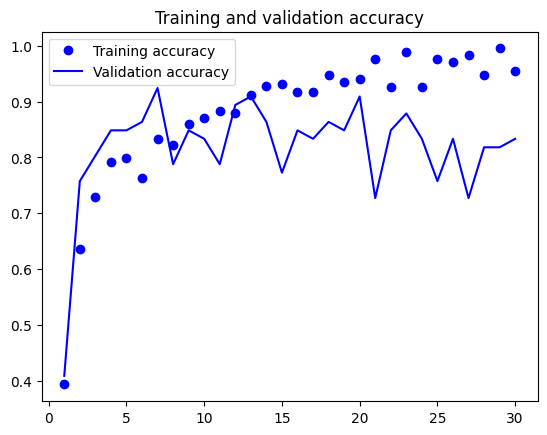

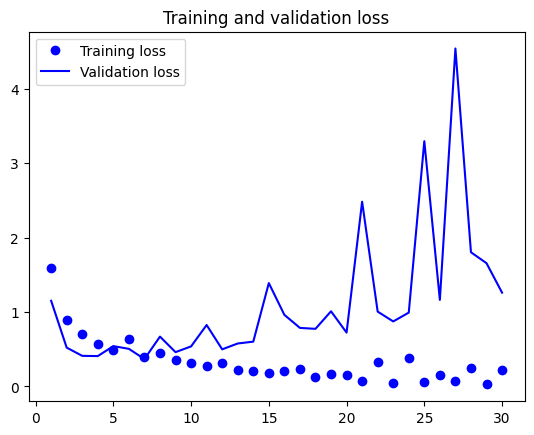

In [ ]:
#Se grafican la precisión y la pérdida
import matplotlib.pyplot as plt
accuracy = history1.history["accuracy"]
val_accuracy = history1.history["val_accuracy"]
loss = history1.history["loss"]
val_loss = history1.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
#Evaluamos nuestro modelo en el cojunto de prueba
test_loss, test_accuracy = model1.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

6/6 [==============================] - 0s 23ms/step - loss: 1.2556 - accuracy: 0.8490
Test accuracy: 84.90%
Test loss: 1.2556


### Guardamos el modelo

In [ ]:
# Se guarda el modelo
model1.save("model1Bsaved") #la B representa que es con el conjunto Balanced

In [ ]:
loaded_model1_saved = tf.keras.models.load_model("model1Bsaved")
loaded_model1_saved.evaluate(test_ds)

6/6 [==============================] - 0s 25ms/step - loss: 1.2556 - accuracy: 0.8490


[1.2555770874023438, 0.8489583134651184]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
drive.mount('/content/drive')
loaded_model1_saved.save('/content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model1Bsaved')
!zip -r /content/drive/MyDrive/Model1.zip /content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model1Bsaved

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
updating: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model1Bsaved/ (stored 0%)
updating: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model1Bsaved/variables/ (stored 0%)
updating: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model1Bsaved/variables/variables.data-00000-of-00001 (deflated 7%)
updating: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model1Bsaved/variables/variables.index (deflated 57%)
updating: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model1Bsaved/assets/ (stored 0%)
updating: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model1Bsaved/saved_model.pb (deflated 88%)
updating: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model1Bsaved/fingerprint.pb (stored 0%)
updating: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model1Bsaved/keras_metadata.pb (deflated 92%)


### Reusando el modelo

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from tensorflow.keras.models import load_model

# donde esta el modelo
model1saved_path = '/content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model1Bsaved'

# cargamos el modelo
model1saved_reloaded = load_model(model1saved_path)


In [ ]:
model1saved_reloaded.evaluate(test_ds)


6/6 [==============================] - 0s 24ms/step - loss: 1.2556 - accuracy: 0.8490


[1.2555770874023438, 0.8489583134651184]


# Model 2: Data Augmentation, Batch Normalization y Dropout

## Model2

In [ ]:
def create_model2(num_classes):

#Hay que dejar en claro que solo le damos mas diversidad a como se aumentan las imagenes
#cada imagen se aumenta 19 veces (el número de batches)
#O sea, 11438 imagenes en lugar de nuestras 602
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),  #Se define un segundo modelo aplicando giros horizontales y verticales
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.2),
        tf.keras.layers.RandomContrast(0.3),             #También se aplican rotaciones, zoom y contraste
    ])

  #Para este segundo modelo también se aplica convolución y Max-Pooling, así como las funciones ReLu y Softmax
    model = tf.keras.Sequential([
        tf.keras.layers.Rescaling(1./255),
        data_augmentation,
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(), #normaliza para su batch en lugar de todo el conjunto
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'), #notese que quitamos la capa extra
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),                                #En este caso se añade un dropout de 0.5 para disminuir el sobreajuste como el ejemplo del banco
        tf.keras.layers.Dense(num_classes, activation = 'softmax')
    ])

    model.compile(optimizer='rmsprop',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits= False),
                  metrics=['accuracy'])

    return model

In [ ]:
model2 = create_model2(num_classes)

In [ ]:
history2 = model2.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
)

Epoch 1/30
19/19 [==============================] - 5s 82ms/step - loss: 0.9564 - accuracy: 0.7093 - val_loss: 1.1003 - val_accuracy: 0.5152
Epoch 2/30
19/19 [==============================] - 1s 70ms/step - loss: 0.5526 - accuracy: 0.8090 - val_loss: 1.1412 - val_accuracy: 0.5152
Epoch 3/30
19/19 [==============================] - 1s 70ms/step - loss: 0.5562 - accuracy: 0.8156 - val_loss: 1.4253 - val_accuracy: 0.3030
Epoch 4/30
19/19 [==============================] - 1s 70ms/step - loss: 0.4569 - accuracy: 0.8422 - val_loss: 2.3341 - val_accuracy: 0.3030
Epoch 5/30
19/19 [==============================] - 1s 71ms/step - loss: 0.4368 - accuracy: 0.8439 - val_loss: 1.8226 - val_accuracy: 0.3030
Epoch 6/30
19/19 [==============================] - 1s 73ms/step - loss: 0.3534 - accuracy: 0.8688 - val_loss: 2.5994 - val_accuracy: 0.2576
Epoch 7/30
19/19 [==============================] - 1s 74ms/step - loss: 0.3563 - accuracy: 0.8621 - val_loss: 2.5970 - val_accuracy: 0.2121
Epoch 8/30
19

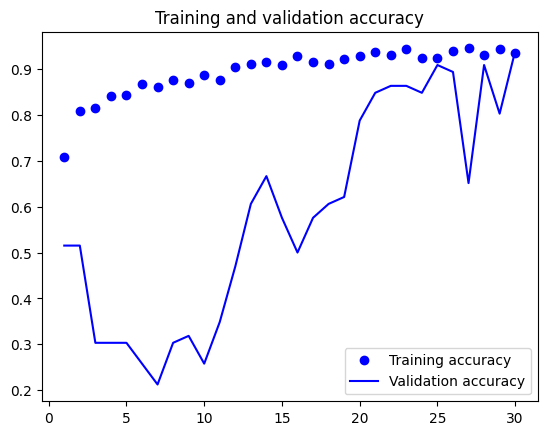

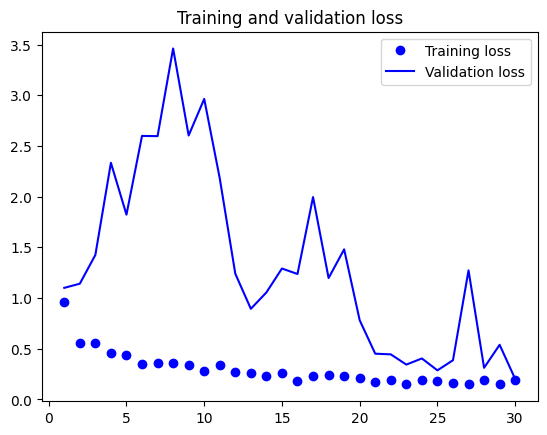

In [ ]:
import matplotlib.pyplot as plt
accuracy = history2.history["accuracy"]
val_accuracy = history2.history["val_accuracy"]
loss = history2.history["loss"]
val_loss = history2.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model2.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

6/6 [==============================] - 0s 26ms/step - loss: 0.2850 - accuracy: 0.9062
Test accuracy: 90.62%
Test loss: 0.2850


### Guardamos el modelo

In [ ]:
model2.save("model2Bsaved")

In [ ]:
loaded_model2_saved = tf.keras.models.load_model("model2Bsaved")
loaded_model2_saved.evaluate(test_ds)

6/6 [==============================] - 0s 26ms/step - loss: 0.2850 - accuracy: 0.9062


[0.28495779633522034, 0.90625]

In [ ]:
drive.mount('/content/drive')
loaded_model2_saved.save('/content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model2Bsaved')
!zip -r /content/drive/MyDrive/Model2.zip /content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model2Bsaved

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model2Bsaved/ (stored 0%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model2Bsaved/variables/ (stored 0%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model2Bsaved/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model2Bsaved/variables/variables.index (deflated 65%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model2Bsaved/assets/ (stored 0%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model2Bsaved/saved_model.pb (deflated 88%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model2Bsaved/fingerprint.pb (stored 0%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model2Bsaved/keras_metadata.pb (deflated 93%)


### Reusamos el modelo

In [ ]:
from tensorflow.keras.models import load_model

model2saved_path = '/content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model2Bsaved'


model2saved_reloaded = load_model(model2saved_path)

In [ ]:
model2saved_reloaded.evaluate(test_ds)

6/6 [==============================] - 0s 26ms/step - loss: 0.2850 - accuracy: 0.9062


[0.28495779633522034, 0.90625]

# Modelo 3: Early Stopping and Learning Rate


## Modelo 3

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
#Usamos early stopping donde monitoremaos la val_loss
#patience se reifere al nuúmero de epochs que debe esperar antes de para el modelo
#usa los mejores pesospara val_loss  en lugar de todos
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

#Se define también el callback de learning rate reduction
#factor se refiere a que reduce el learning rate cuando la val_loss se estanca
#es como nuestro limite inferior para que no deje de aprender
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5)


In [ ]:
#Se aplica el modelo 2 pero añadiendo los dos callbacks anteriores
model3 = create_model2(num_classes)

In [ ]:
history3 = model3.fit(
  train_ds,
  validation_data=val_ds,
  epochs=50,               #Para este caso se prueban 50 épocas para asegurar que se apliquen los callbacks
  callbacks=[early_stopping, reduce_lr]
)

Epoch 1/50
19/19 [==============================] - 4s 89ms/step - loss: 0.9444 - accuracy: 0.7193 - val_loss: 1.1798 - val_accuracy: 0.4848 - lr: 0.0010
Epoch 2/50
19/19 [==============================] - 1s 71ms/step - loss: 0.6088 - accuracy: 0.7957 - val_loss: 1.4263 - val_accuracy: 0.2727 - lr: 0.0010
Epoch 3/50
19/19 [==============================] - 1s 73ms/step - loss: 0.5233 - accuracy: 0.8156 - val_loss: 1.9952 - val_accuracy: 0.2121 - lr: 0.0010
Epoch 4/50
19/19 [==============================] - 1s 71ms/step - loss: 0.4527 - accuracy: 0.8488 - val_loss: 2.3124 - val_accuracy: 0.2121 - lr: 0.0010
Epoch 5/50
19/19 [==============================] - 1s 71ms/step - loss: 0.3376 - accuracy: 0.8821 - val_loss: 2.4895 - val_accuracy: 0.2121 - lr: 2.0000e-04
Epoch 6/50
19/19 [==============================] - 1s 74ms/step - loss: 0.2704 - accuracy: 0.9070 - val_loss: 2.6617 - val_accuracy: 0.2273 - lr: 2.0000e-04


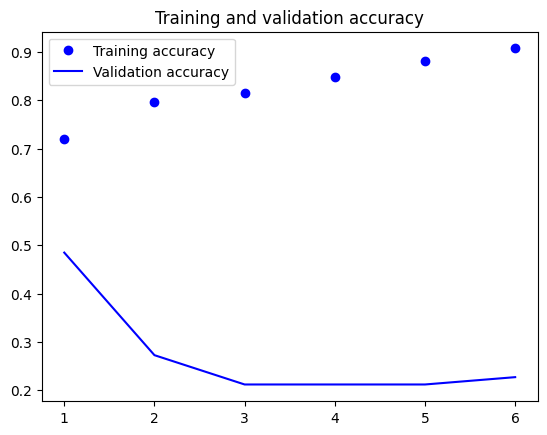

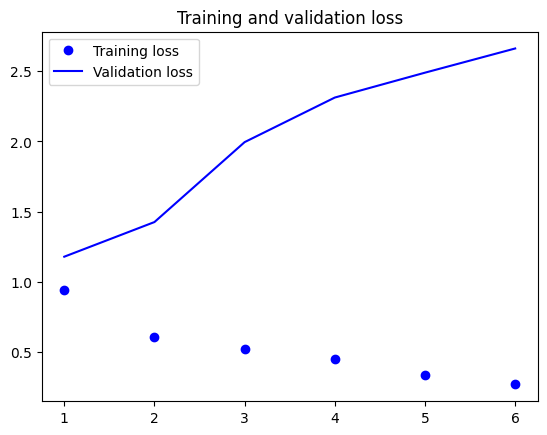

In [ ]:
import matplotlib.pyplot as plt
accuracy = history3.history["accuracy"]
val_accuracy = history3.history["val_accuracy"]
loss = history3.history["loss"]
val_loss = history3.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model3.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

6/6 [==============================] - 0s 25ms/step - loss: 1.1342 - accuracy: 0.5312
Test accuracy: 53.12%
Test loss: 1.1342


### Guardamos el Modelo

In [ ]:
model3.save("model3Bsaved")

In [ ]:
loaded_model3_saved = tf.keras.models.load_model("model3Bsaved")
loaded_model3_saved.evaluate(test_ds)

6/6 [==============================] - 0s 26ms/step - loss: 1.1342 - accuracy: 0.5312


[1.1342203617095947, 0.53125]

In [ ]:
drive.mount('/content/drive')
loaded_model3_saved.save('/content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model3Bsaved')
!zip -r /content/drive/MyDrive/Model3.zip /content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model3Bsaved

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
updating: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model3Bsaved/ (stored 0%)
updating: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model3Bsaved/variables/ (stored 0%)
updating: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model3Bsaved/variables/variables.data-00000-of-00001 (deflated 7%)
updating: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model3Bsaved/variables/variables.index (deflated 65%)
updating: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model3Bsaved/assets/ (stored 0%)
updating: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model3Bsaved/saved_model.pb (deflated 89%)
updating: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model3Bsaved/fingerprint.pb (stored 0%)
updating: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model3Bsaved/keras_metadata.pb (deflated 93%)


# Modelo 4: Transfer Learning

## Model 4 (VGG16)

In [ ]:
#Para aplicar transfer learning se baja el modelo VGG16
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3))
conv_base.trainable = False

58889256/58889256 [==============================] - 4s 0us/step


In [ ]:
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = keras.applications.vgg16.preprocess_input(images)   #Se toman las imágenes preprocesadas
        features = conv_base.predict(preprocessed_images)                         #Se toman las predicciones del modelo VGG16
        all_features.append(features)
        all_labels.append(labels)                                                 #La información se almacena en las dos listas vacías
    return np.concatenate(all_features), np.concatenate(all_labels)               #Se concatenan las listas de características y etiquetas

#Se aplica la función anterior a los conjuntos de datos de entrenamiento, validación y prueba para obtener las características y etiquetas
train_features, train_labels =  get_features_and_labels(train_ds)
val_features, val_labels =  get_features_and_labels(val_ds)
test_features, test_labels =  get_features_and_labels(test_ds)

1/1 [==============================] - 0s 34ms/step


In [ ]:
train_features.shape

(602, 7, 7, 512)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

#Se define el modelo 4 a partir del modelo base VGG16
#Primero se aplica un flip, rotación y zoom, luego se aplica VGG16
def create_model4(num_classes):
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),               #Rotación hasta 0.2 radianes
        layers.RandomZoom(0.2),                   #Zoom hasta el 20%
    ])

    # Define the VGG16 base model without the top classification layer
    conv_base = tf.keras.applications.VGG16(include_top=False, input_shape=(224, 224, 3))

    model = tf.keras.Sequential([
        layers.Rescaling(1./255, input_shape=(224, 224, 3)),     #Se aplica un reescalamiento
        data_augmentation,
        conv_base,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),                    #Relu para no linearidad
        layers.Dropout(0.5),                                     #Dropout para evitar el sobreajuste
        layers.Dense(num_classes, activation='softmax')          #Softmax para obtener las probabilidades
    ])

    #Se compila el modelo con optimizador rmsprop, categorical crossentropy y de métrica accuracy
    model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-5),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                  metrics=['accuracy'])

    return model

In [ ]:
#Se define el modelo a num_clases=4
model4 = create_model4(num_classes)

In [ ]:
history4 = model4.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds
    )

Epoch 1/20
19/19 [==============================] - 36s 1s/step - loss: 1.3363 - accuracy: 0.3904 - val_loss: 0.9658 - val_accuracy: 0.7121
Epoch 2/20
19/19 [==============================] - 8s 419ms/step - loss: 0.8975 - accuracy: 0.6611 - val_loss: 0.5968 - val_accuracy: 0.8182
Epoch 3/20
19/19 [==============================] - 8s 425ms/step - loss: 0.5612 - accuracy: 0.8040 - val_loss: 0.3903 - val_accuracy: 0.8788
Epoch 4/20
19/19 [==============================] - 8s 428ms/step - loss: 0.3863 - accuracy: 0.8621 - val_loss: 0.3762 - val_accuracy: 0.8788
Epoch 5/20
19/19 [==============================] - 8s 432ms/step - loss: 0.2974 - accuracy: 0.9003 - val_loss: 0.4008 - val_accuracy: 0.8636
Epoch 6/20
19/19 [==============================] - 8s 442ms/step - loss: 0.2190 - accuracy: 0.9269 - val_loss: 0.3158 - val_accuracy: 0.8939
Epoch 7/20
19/19 [==============================] - 8s 440ms/step - loss: 0.2244 - accuracy: 0.9236 - val_loss: 0.2463 - val_accuracy: 0.9242
Epoch 8/

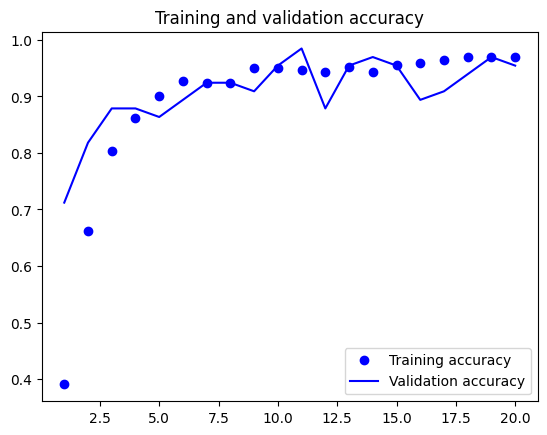

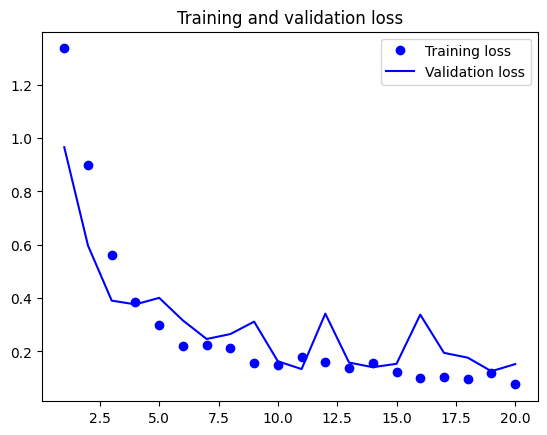

In [ ]:
import matplotlib.pyplot as plt
accuracy = history4.history["accuracy"]
val_accuracy = history4.history["val_accuracy"]
loss = history4.history["loss"]
val_loss = history4.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model4.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

6/6 [==============================] - 1s 130ms/step - loss: 0.1264 - accuracy: 0.9635
Test accuracy: 96.35%
Test loss: 0.1264


### Guardamos el historial

In [ ]:
import pandas as pd
#de dict a pd
hist_df = pd.DataFrame(history4.history)
#de pd a csv y a la bolsa
hist_csv_file = 'history4.csv'
with open(hist_csv_file, mode='w') as f:
    hist_df.to_csv(f)

### Guardamos el modelo

In [ ]:
model4.save("model4Bsaved")

In [ ]:
loaded_model4_saved = tf.keras.models.load_model("model4Bsaved")
loaded_model4_saved.evaluate(test_ds)

6/6 [==============================] - 1s 131ms/step - loss: 0.1803 - accuracy: 0.9635


[0.18034493923187256, 0.9635416865348816]

In [ ]:
drive.mount('/content/drive')
loaded_model4_saved.save('/content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4Bsaved')
!zip -r /content/drive/MyDrive/Model4.zip /content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4Bsaved

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4Bsaved/ (stored 0%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4Bsaved/variables/ (stored 0%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4Bsaved/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4Bsaved/variables/variables.index (deflated 65%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4Bsaved/assets/ (stored 0%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4Bsaved/saved_model.pb (deflated 89%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4Bsaved/fingerprint.pb (stored 0%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4Bsaved/keras_metadata.pb (deflated 96%)


## Model 4.2 (VGG19)

In [ ]:
#Se repite el proceso del modelo 4 pero utilizando ahora VGG19
conv_base = keras.applications.vgg19.VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3))
conv_base.trainable = False

80134624/80134624 [==============================] - 5s 0us/step


In [ ]:
train_features, train_labels =  get_features_and_labels(train_ds)
val_features, val_labels =  get_features_and_labels(val_ds)
test_features, test_labels =  get_features_and_labels(test_ds)

1/1 [==============================] - 0s 26ms/step


In [ ]:
train_features.shape

(602, 7, 7, 512)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

def create_model4_2(num_classes):
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
    ])

    # Define the VGG19 base model without the top classification layer
    conv_base = tf.keras.applications.VGG19(include_top=False, input_shape=(224, 224, 3))

    model = tf.keras.Sequential([
        layers.Rescaling(1./255, input_shape=(224, 224, 3)),
        data_augmentation,
        conv_base,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-5),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                  metrics=['accuracy'])

    return model

In [ ]:
model4_2 = create_model4_2(num_classes)

In [ ]:
history4_2 = model4_2.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds
    )

Epoch 1/30
19/19 [==============================] - 14s 517ms/step - loss: 1.3872 - accuracy: 0.3937 - val_loss: 1.0470 - val_accuracy: 0.5606
Epoch 2/30
19/19 [==============================] - 10s 519ms/step - loss: 0.9143 - accuracy: 0.6262 - val_loss: 0.7037 - val_accuracy: 0.6970
Epoch 3/30
19/19 [==============================] - 10s 511ms/step - loss: 0.5843 - accuracy: 0.7874 - val_loss: 0.4122 - val_accuracy: 0.8030
Epoch 4/30
19/19 [==============================] - 10s 534ms/step - loss: 0.3503 - accuracy: 0.8771 - val_loss: 0.2339 - val_accuracy: 0.9394
Epoch 5/30
19/19 [==============================] - 10s 525ms/step - loss: 0.3302 - accuracy: 0.8738 - val_loss: 0.2297 - val_accuracy: 0.9242
Epoch 6/30
19/19 [==============================] - 10s 538ms/step - loss: 0.2893 - accuracy: 0.8987 - val_loss: 0.2012 - val_accuracy: 0.9545
Epoch 7/30
19/19 [==============================] - 10s 537ms/step - loss: 0.2382 - accuracy: 0.9219 - val_loss: 0.1388 - val_accuracy: 0.9697

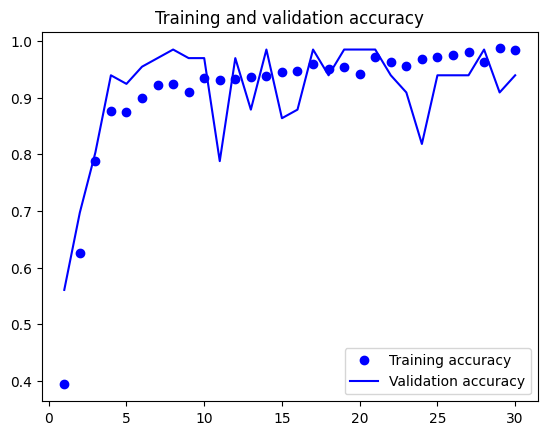

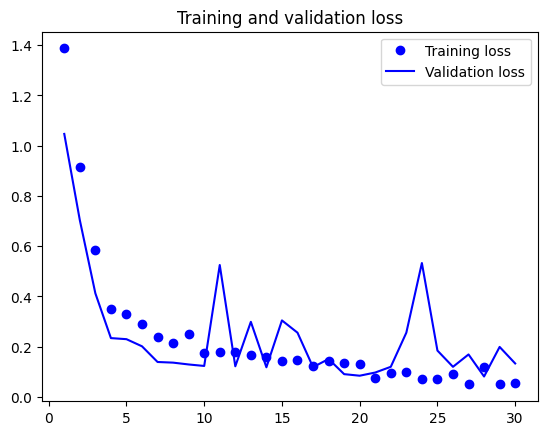

In [ ]:
import matplotlib.pyplot as plt
accuracy = history4_2.history["accuracy"]
val_accuracy = history4_2.history["val_accuracy"]
loss = history4_2.history["loss"]
val_loss = history4_2.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model4_2.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

6/6 [==============================] - 1s 154ms/step - loss: 0.0974 - accuracy: 0.9583
Test accuracy: 95.83%
Test loss: 0.0974


### Guardamos el historial

In [ ]:
hist_df = pd.DataFrame(history4_2.history)
hist_csv_file = 'history4_2.csv'
with open(hist_csv_file, mode='w') as f:
    hist_df.to_csv(f)

### Guardamos el modelo

In [ ]:
model4_2.save("model4_2Bsaved")

In [ ]:
loaded_model4_2_saved = tf.keras.models.load_model("model4_2Bsaved")
loaded_model4_2_saved.evaluate(test_ds)

6/6 [==============================] - 1s 155ms/step - loss: 0.1329 - accuracy: 0.9583


[0.13289599120616913, 0.9583333134651184]

In [ ]:
drive.mount('/content/drive')
loaded_model4_2_saved.save('/content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4_2Bsaved')
!zip -r /content/drive/MyDrive/Model4_2.zip /content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4_2Bsaved

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4_2Bsaved/ (stored 0%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4_2Bsaved/variables/ (stored 0%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4_2Bsaved/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4_2Bsaved/variables/variables.index (deflated 66%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4_2Bsaved/assets/ (stored 0%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4_2Bsaved/saved_model.pb (deflated 90%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4_2Bsaved/fingerprint.pb (stored 0%)
  adding: content/drive/MyDrive/IRN_ULTIMATE/BALANCED_MODELS/model4_2Bsaved/keras_metadata.pb (deflated 96%)


## Model 4.3 (Xception)

In [ ]:
#Ahora en vez de VGG19 se utiliza Xception
conv_base = keras.applications.xception.Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3))
conv_base.trainable = False

83683744/83683744 [==============================] - 5s 0us/step


In [ ]:
train_features, train_labels =  get_features_and_labels(train_ds)
val_features, val_labels =  get_features_and_labels(val_ds)
test_features, test_labels =  get_features_and_labels(test_ds)

1/1 [==============================] - 0s 30ms/step


In [ ]:
train_features.shape

(602, 7, 7, 2048)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

def create_model4_3(num_classes):
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
    ])

    # Define the Xception base model without the top classification layer
    conv_base = tf.keras.applications.Xception(include_top=False, input_shape=(224, 224, 3))

    model = tf.keras.Sequential([
        layers.Rescaling(1./255, input_shape=(224, 224, 3)),
        data_augmentation,
        conv_base,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-5),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                  metrics=['accuracy'])

    return model

In [ ]:
model4_3 = create_model4_3(num_classes)

In [ ]:
history4_3 = model4_3.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds
    )

Epoch 1/30
19/19 [==============================] - 33s 730ms/step - loss: 1.2402 - accuracy: 0.4485 - val_loss: 1.1393 - val_accuracy: 0.5455
Epoch 2/30
19/19 [==============================] - 9s 474ms/step - loss: 0.8298 - accuracy: 0.7093 - val_loss: 0.8107 - val_accuracy: 0.7727
Epoch 3/30
19/19 [==============================] - 9s 483ms/step - loss: 0.6231 - accuracy: 0.8023 - val_loss: 0.5975 - val_accuracy: 0.8030
Epoch 4/30
19/19 [==============================] - 9s 491ms/step - loss: 0.4304 - accuracy: 0.8738 - val_loss: 0.5208 - val_accuracy: 0.8182
Epoch 5/30
19/19 [==============================] - 9s 495ms/step - loss: 0.3245 - accuracy: 0.9103 - val_loss: 0.3446 - val_accuracy: 0.9091
Epoch 6/30
19/19 [==============================] - 9s 500ms/step - loss: 0.2743 - accuracy: 0.9219 - val_loss: 0.3323 - val_accuracy: 0.9091
Epoch 7/30
19/19 [==============================] - 10s 507ms/step - loss: 0.2235 - accuracy: 0.9302 - val_loss: 0.2878 - val_accuracy: 0.8939
Epoc

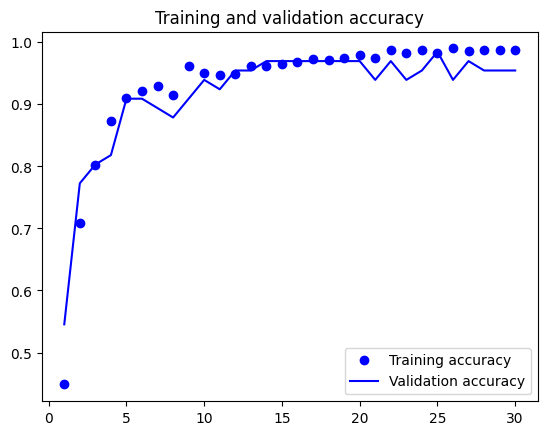

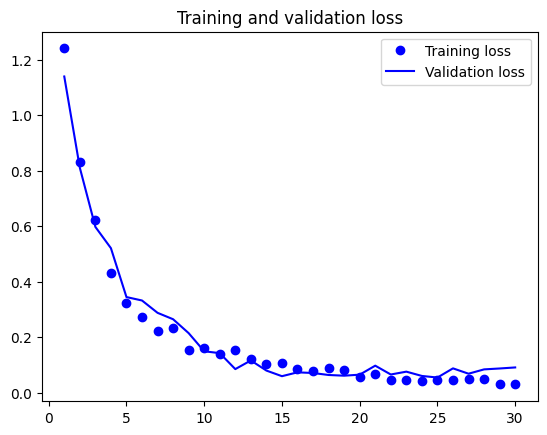

In [ ]:
import matplotlib.pyplot as plt
accuracy = history4_3.history["accuracy"]
val_accuracy = history4_3.history["val_accuracy"]
loss = history4_3.history["loss"]
val_loss = history4_3.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model4_3.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

6/6 [==============================] - 1s 128ms/step - loss: 0.0817 - accuracy: 0.9740
Test accuracy: 97.40%
Test loss: 0.0817


No, ya no guardamos los modelos porque pesan mucho.

## Model 4.4 (ResNet50V2)

In [ ]:
#En este caso se utiliza ResNet50 V2
conv_base = keras.applications.ResNet50V2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3))
conv_base.trainable = False

94668760/94668760 [==============================] - 6s 0us/step


In [ ]:
train_features, train_labels =  get_features_and_labels(train_ds)
val_features, val_labels =  get_features_and_labels(val_ds)
test_features, test_labels =  get_features_and_labels(test_ds)

1/1 [==============================] - 0s 28ms/step


In [ ]:
train_features.shape

(602, 7, 7, 2048)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

def create_model4_4(num_classes):
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
    ])

    # Define the ResNet50V2 base model without the top classification layer
    conv_base = tf.keras.applications.ResNet50V2(include_top=False, input_shape=(224, 224, 3))

    model = tf.keras.Sequential([
        layers.Rescaling(1./255, input_shape=(224, 224, 3)),
        data_augmentation,
        conv_base,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-5),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                  metrics=['accuracy'])

    return model

In [ ]:
model4_4 = create_model4_4(num_classes)

In [ ]:
history4_4 = model4_4.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds
    )

Epoch 1/30
19/19 [==============================] - 30s 521ms/step - loss: 2.1020 - accuracy: 0.3638 - val_loss: 1.2387 - val_accuracy: 0.4394
Epoch 2/30
19/19 [==============================] - 6s 299ms/step - loss: 1.4817 - accuracy: 0.5033 - val_loss: 0.9596 - val_accuracy: 0.6212
Epoch 3/30
19/19 [==============================] - 6s 309ms/step - loss: 1.0858 - accuracy: 0.6080 - val_loss: 0.7288 - val_accuracy: 0.6970
Epoch 4/30
19/19 [==============================] - 6s 302ms/step - loss: 0.8517 - accuracy: 0.6728 - val_loss: 0.5420 - val_accuracy: 0.7879
Epoch 5/30
19/19 [==============================] - 6s 303ms/step - loss: 0.7040 - accuracy: 0.7625 - val_loss: 0.4510 - val_accuracy: 0.8030
Epoch 6/30
19/19 [==============================] - 6s 303ms/step - loss: 0.5653 - accuracy: 0.7824 - val_loss: 0.3544 - val_accuracy: 0.8485
Epoch 7/30
19/19 [==============================] - 6s 306ms/step - loss: 0.5419 - accuracy: 0.8206 - val_loss: 0.3063 - val_accuracy: 0.8939
Epoch

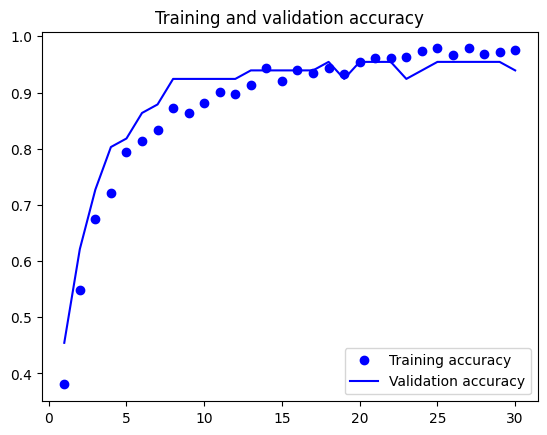

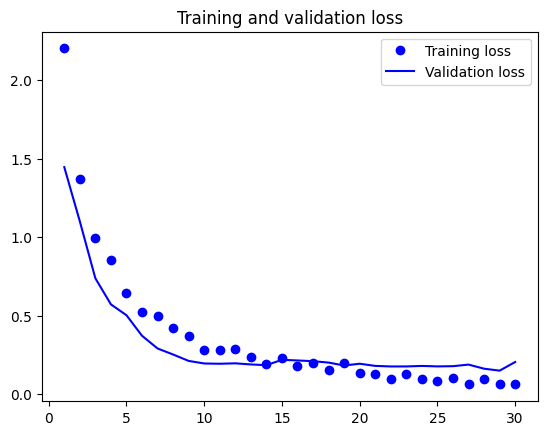

In [ ]:
import matplotlib.pyplot as plt
accuracy = history4_4.history["accuracy"]
val_accuracy = history4_4.history["val_accuracy"]
loss = history4_4.history["loss"]
val_loss = history4_4.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model4_4.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

6/6 [==============================] - 1s 93ms/step - loss: 0.0978 - accuracy: 0.9635
Test accuracy: 96.35%
Test loss: 0.0978


## Model 4.5 (MobileNetV3)

In [ ]:
from tensorflow.keras.applications import MobileNetV3Small, MobileNetV3Large

In [ ]:
#Y por último MobileNet V3
conv_base = MobileNetV3Small(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3))
conv_base.trainable = False

4334752/4334752 [==============================] - 1s 0us/step


In [ ]:
train_features, train_labels =  get_features_and_labels(train_ds)
val_features, val_labels =  get_features_and_labels(val_ds)
test_features, test_labels =  get_features_and_labels(test_ds)

1/1 [==============================] - 0s 38ms/step


In [ ]:
train_features.shape

(602, 7, 7, 576)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

def create_model4_5(num_classes):
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
    ])

    # Define the MobileNetV3 base model without the top classification layer
    conv_base = MobileNetV3Large(include_top=False, input_shape=(224, 224, 3))

    model = tf.keras.Sequential([
        layers.Rescaling(1./255, input_shape=(224, 224, 3)),
        data_augmentation,
        conv_base,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-5),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                  metrics=['accuracy'])

    return model

In [ ]:
model4_5 = create_model4_5(num_classes)

In [ ]:
history4_5 = model4_5.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds
    )

Epoch 1/30
19/19 [==============================] - 20s 188ms/step - loss: 3.2190 - accuracy: 0.3405 - val_loss: 1.5934 - val_accuracy: 0.2576
Epoch 2/30
19/19 [==============================] - 2s 129ms/step - loss: 2.1334 - accuracy: 0.4734 - val_loss: 1.5694 - val_accuracy: 0.2576
Epoch 3/30
19/19 [==============================] - 2s 129ms/step - loss: 1.7483 - accuracy: 0.5598 - val_loss: 1.5489 - val_accuracy: 0.2576
Epoch 4/30
19/19 [==============================] - 2s 125ms/step - loss: 1.3364 - accuracy: 0.6113 - val_loss: 1.5303 - val_accuracy: 0.2576
Epoch 5/30
19/19 [==============================] - 2s 124ms/step - loss: 1.0761 - accuracy: 0.6960 - val_loss: 1.5364 - val_accuracy: 0.2576
Epoch 6/30
19/19 [==============================] - 2s 124ms/step - loss: 0.9955 - accuracy: 0.6993 - val_loss: 1.5325 - val_accuracy: 0.2576
Epoch 7/30
19/19 [==============================] - 2s 125ms/step - loss: 0.8240 - accuracy: 0.7575 - val_loss: 1.5239 - val_accuracy: 0.2576
Epoch

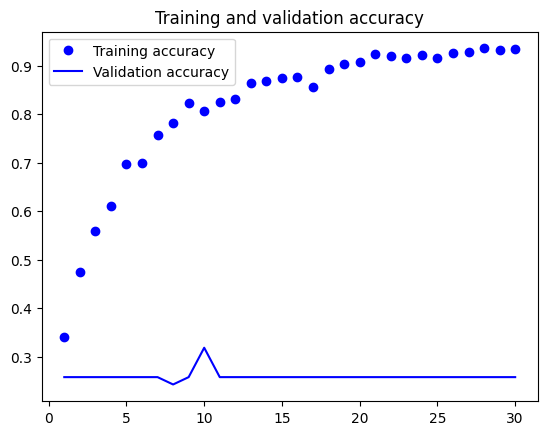

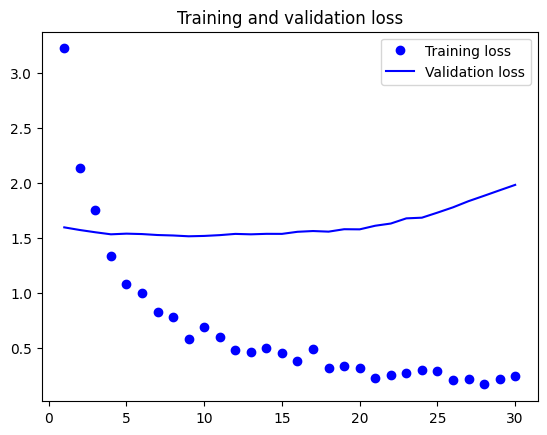

In [ ]:
import matplotlib.pyplot as plt
accuracy = history4_5.history["accuracy"]
val_accuracy = history4_5.history["val_accuracy"]
loss = history4_5.history["loss"]
val_loss = history4_5.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model4_5.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

6/6 [==============================] - 0s 47ms/step - loss: 2.0165 - accuracy: 0.2344
Test accuracy: 23.44%
Test loss: 2.0165
